<a href="https://colab.research.google.com/github/CodeStriker7/comeback_code/blob/main/R2mse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
df = pd.read_csv('noutbuklar_uz.csv')
X = df[['ram_gb', 'ssd_gb', 'cpu_ghz', 'cpu_yadro', 'gpu_vram_gb',
        'ekran_inch', 'ekran_hz', 'ekran_nit', 'batareya_soat',
        'vazn_kg', 'usb_port', 'kamera_mp']]
y = df['narx_mln_som']


In [15]:
# data setni tekshirib kurish
print(1)
print(f"Jami qatorlar: {df.shape[0]}")
print(f"Jami ustunlar: {df.shape[1]}")

print(2)
print(df.head())

print()
print(df.dtypes)

print()
print(df.isnull().sum())


print()
print("STATISTIKA")
print(df.describe().round(2))


# x y uzgaruvchilar

X = df[['ram_gb', 'ssd_gb', 'cpu_ghz', 'cpu_yadro', 'gpu_vram_gb',
        'ekran_inch', 'ekran_hz', 'ekran_nit', 'batareya_soat',
        'vazn_kg', 'usb_port', 'kamera_mp']]

y = df['narx_mln_som']

print(f"X (kiruvchi) o'lcham : {X.shape}  →  {X.shape[0]} ta namuna, {X.shape[1]} ta xususiyat")
print(f"y (chiquvchi) o'lcham: {y.shape}  →  {y.shape[0]} ta narx qiymati")
print()

# Train - Test 80% , 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("TRAIN/TEST BO'LINISHI")
print(f"Train set (o'qitish): {X_train.shape[0]} ta namuna  (80%)")
print(f"Test  set (sinash)  : {X_test.shape[0]} ta namuna  (20%)")
print()

1
Jami qatorlar: 200
Jami ustunlar: 14
2
    brand  ram_gb  ssd_gb  cpu_ghz  cpu_yadro  gpu_vram_gb  ekran_inch  \
0     MSI     4.0   128.0      3.1        6.0          0.0        13.3   
1    Asus    16.0   512.0      2.8        2.0          0.0        17.3   
2    Acer     8.0   512.0      2.3        4.0          0.0        17.3   
3     MSI     8.0   512.0      3.4        4.0          2.0        17.3   
4  Lenovo    32.0   512.0      3.1        2.0          2.0        17.3   

   ekran_hz  ekran_nit  batareya_soat  vazn_kg  usb_port  kamera_mp  \
0      60.0      300.0            9.8     2.31       4.0        2.0   
1     144.0      300.0            6.0     1.21       3.0        2.0   
2      60.0      250.0            5.2     2.72       2.0        2.0   
3      90.0      300.0            6.5     1.27       3.0        1.0   
4     120.0      300.0            6.1     2.69       3.0        5.0   

   narx_mln_som  
0          9.02  
1         11.77  
2          9.40  
3         11.25

In [16]:

print("MODEL YARATISH VA O'RGATISH")

model = LinearRegression()
model.fit(X_train, y_train)


print("MODEL KOEFFITSIENTLARI")
print(f"{'Xususiyat':<18} {'Koeffitsient':>14}")
print("-" * 34)
for xususiyat, koef in zip(X.columns, model.coef_):
    print(f"{xususiyat:<18} {koef:>14.5f}")
print(f"{'Intercept (b0)':<18} {model.intercept_:>14.5f}")
print()

y_pred = model.predict(X_test)

print("bashorat")
print(f"{'Haqiqiy narx':>15}  {'Bashorat narx':>15}  {'Farq':>10}")

for haqiqiy, bashorat in zip(y_test.values[:5], y_pred[:5]):
    farq = haqiqiy - bashorat
    print(f"{haqiqiy:>13.2f}  {bashorat:>13.2f}  {farq:>10.2f}")
print()

MODEL YARATISH VA O'RGATISH
MODEL KOEFFITSIENTLARI
Xususiyat            Koeffitsient
----------------------------------
ram_gb                    0.14087
ssd_gb                    0.00216
cpu_ghz                   0.71678
cpu_yadro                 0.29946
gpu_vram_gb               0.39213
ekran_inch                0.15796
ekran_hz                  0.01652
ekran_nit                 0.00137
batareya_soat             0.08835
vazn_kg                  -0.07810
usb_port                  0.06690
kamera_mp                 0.04333
Intercept (b0)           -0.60479

bashorat
   Haqiqiy narx    Bashorat narx        Farq
        13.17          12.88        0.29
        13.44          12.79        0.65
        10.52          10.01        0.51
        11.13           9.84        1.29
        11.36          11.08        0.28



In [17]:
print("MODELNI BAHOLASH")

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(y_test.values - y_pred))

print(f"R²   (Aniqlik darajasi) : {r2:.4f}  →  model {r2*100:.1f}% aniq")
print(f"MSE  (O'rta kv. xato)   : {mse:.4f}")
print(f"RMSE (Ildiz MSE)        : {rmse:.4f}  →  xato ±{rmse:.2f} mln so'm")
print(f"MAE  (O'rta abs. xato)  : {mae:.4f}  →  o'rtacha ±{mae:.2f} mln so'm")
print()

# R²
if r2 >= 0.9:
    print("Xulosa: Model JUDA YAXSHI ishlayapti! (R² >= 0.90)")
elif r2 >= 0.7:
    print("Xulosa: Model YAXSHI ishlayapti (R² >= 0.70)")
elif r2 >= 0.5:
    print("Xulosa: Model O'RTACHA ishlayapti (R² >= 0.50)")
else:
    print("Xulosa: Model YAXSHILASH kerak (R² < 0.50)")
print()

MODELNI BAHOLASH
R²   (Aniqlik darajasi) : 0.8821  →  model 88.2% aniq
MSE  (O'rta kv. xato)   : 0.3240
RMSE (Ildiz MSE)        : 0.5692  →  xato ±0.57 mln so'm
MAE  (O'rta abs. xato)  : 0.4553  →  o'rtacha ±0.46 mln so'm

Xulosa: Model YAXSHI ishlayapti (R² >= 0.70)



GRAFIK CHIZISH


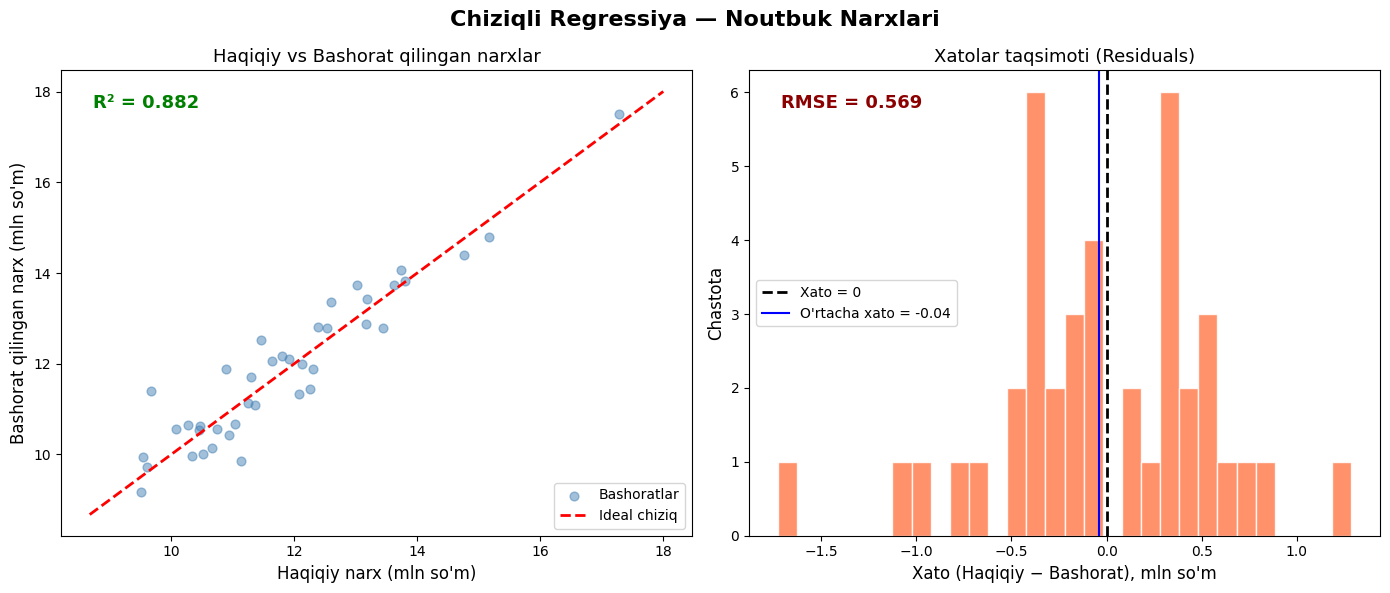

In [18]:
print("GRAFIK CHIZISH")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Chiziqli Regressiya — Noutbuk Narxlari", fontsize=16, fontweight='bold')

# Grafik 1: Haqiqiy vs Bashorat
ax1 = axes[0]
ax1.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=40, label='Bashoratlar')

# Ideal chiziq
min_val = min(y_test.min(), y_pred.min()) - 0.5
max_val = max(y_test.max(), y_pred.max()) + 0.5
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal chiziq')

ax1.set_xlabel("Haqiqiy narx (mln so'm)", fontsize=12)
ax1.set_ylabel("Bashorat qilingan narx (mln so'm)", fontsize=12)
ax1.set_title("Haqiqiy vs Bashorat qilingan narxlar", fontsize=13)
ax1.legend()
ax1.text(0.05, 0.92, f"R² = {r2:.3f}", transform=ax1.transAxes,
         fontsize=13, color='green', fontweight='bold')

# Grafik 2: Xatolar taqsimoti
ax2 = axes[1]
xatolar = y_test.values - y_pred
ax2.hist(xatolar, bins=30, color='coral', edgecolor='white', alpha=0.85)
ax2.axvline(x=0, color='black', linestyle='--', lw=2, label='Xato = 0')
ax2.axvline(x=xatolar.mean(), color='blue', linestyle='-', lw=1.5,
            label=f"O'rtacha xato = {xatolar.mean():.2f}")

ax2.set_xlabel("Xato (Haqiqiy − Bashorat), mln so'm", fontsize=12)
ax2.set_ylabel("Chastota", fontsize=12)
ax2.set_title("Xatolar taqsimoti (Residuals)", fontsize=13)
ax2.legend()
ax2.text(0.05, 0.92, f"RMSE = {rmse:.3f}", transform=ax2.transAxes,
         fontsize=13, color='darkred', fontweight='bold')

plt.tight_layout()
plt.savefig('regressiya_natijalar.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
print(f"  - Jami ma'lumot       : {len(df)} ta noutbuk")
print(f"  - O'qitish (train)    : {X_train.shape[0]} ta namuna")
print(f"  - Sinash (test)       : {X_test.shape[0]} ta namuna")
print(f"  - Xususiyatlar soni   : {X.shape[1]} ta")
print()
print(f"  - R² (aniqlik)        : {r2:.4f}  ({r2*100:.1f}%)")
print(f"  - RMSE (xato)         : {rmse:.4f} mln so'm")
print(f"  - MAE  (abs xato)     : {mae:.4f} mln so'm")
print()
print("ENG MUHIM XUSUSIYATLAR (koeffitsient bo'yicha):")
koef_df = pd.DataFrame({
    'Xususiyat': X.columns,
    'Koeffitsient': model.coef_,
    'Absolut qiymat': np.abs(model.coef_)
}).sort_values('Absolut qiymat', ascending=False)

for _, qator in koef_df.iterrows():
    print(f"  {qator['Xususiyat']:<18}: {qator['Koeffitsient']:>8.4f}")
print()


  - Jami ma'lumot       : 200 ta noutbuk
  - O'qitish (train)    : 160 ta namuna
  - Sinash (test)       : 40 ta namuna
  - Xususiyatlar soni   : 12 ta

  - R² (aniqlik)        : 0.8821  (88.2%)
  - RMSE (xato)         : 0.5692 mln so'm
  - MAE  (abs xato)     : 0.4553 mln so'm

ENG MUHIM XUSUSIYATLAR (koeffitsient bo'yicha):
  cpu_ghz           :   0.7168
  gpu_vram_gb       :   0.3921
  cpu_yadro         :   0.2995
  ekran_inch        :   0.1580
  ram_gb            :   0.1409
  batareya_soat     :   0.0883
  vazn_kg           :  -0.0781
  usb_port          :   0.0669
  kamera_mp         :   0.0433
  ekran_hz          :   0.0165
  ssd_gb            :   0.0022
  ekran_nit         :   0.0014

